In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
# Base data folder
WORK = Path(os.environ.get("WORK", Path.cwd()))
DATA = WORK / "color-concept-entanglement" / "data"

In [3]:
profile_df = pd.read_csv(DATA / "prolific_stimuli" / "prolific_results_by_profile.csv")
trial_df = pd.read_csv(DATA / "prolific_stimuli" / "prolific_results_by_trial.csv")
completed_df = pd.read_csv(DATA / "prolific_stimuli" / "prolific_results_by_trial_completed.csv")

/tmp/ipykernel_3685132/1440600842.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  trial_df = pd.read_csv(DATA / "prolific_stimuli" / "prolific_results_by_trial.csv")


In [4]:
priors_df = pd.read_csv(DATA / "prolific_stimuli" / "stimulus_table_image_priors_prolific_fractions.csv")
cf_df = pd.read_csv(DATA / "prolific_stimuli" / "stimulus_table_counterfact_prolific_fractions.csv")
shape_df = pd.read_csv(DATA / "prolific_stimuli" / "stimulus_table_shapes_prolific_fractions.csv")

stimulus_df = pd.concat([priors_df, cf_df, shape_df], ignore_index=True)

In [5]:
completed_df = completed_df.merge(
    stimulus_df[["image_path", "nonwhite_fraction"]],
    on=["image_path"],
    how="left"
)
completed_df["corr_percent_colored"] = round(completed_df["percent_colored"] * (1 - completed_df["nonwhite_fraction"]), 2)

In [6]:
test = completed_df.copy()
display(test)

,PROLIFIC_PID,certainty_change_count,color_time,distractor_errors,exit_reason,exit_time,experiment_start_time,final_certainty,finish_time,first_certainty_time,...,task_type,time_elapsed,timed_out,timeout_time,trial_index,trial_type,variant_region,manipulation_color,nonwhite_fraction,corr_percent_colored
0,5dd2ccf12e6c772de06f525b,1.0,4524.9,0.0,completed,1770117186247,1770116663290,NaN,9561.4,8552.4,...,color_judgment,11300,True,1.770117e+12,1,html-button-response,FG,red,0.141040,42.95
1,5dd2ccf12e6c772de06f525b,1.0,3133.1,0.0,completed,1770117186247,1770116663290,NaN,6802.6,5922.1,...,color_judgment,18107,True,1.770117e+12,2,html-button-response,BG,purple,0.099546,90.05
2,5dd2ccf12e6c772de06f525b,1.0,4097.5,0.0,completed,1770117186247,1770116663290,NaN,7002.5,6099.7,...,color_judgment,25118,True,1.770117e+12,3,html-button-response,FG,red,0.678257,1.61
3,5dd2ccf12e6c772de06f525b,1.0,2973.6,0.0,completed,1770117186247,1770116663290,NaN,5509.3,4611.7,...,color_judgment,30634,True,1.770117e+12,4,html-button-response,FG,grey,0.137940,4.31
4,5dd2ccf12e6c772de06f525b,1.0,2721.5,0.0,completed,1770117186247,1770116663290,NaN,5793.8,4412.5,...,color_judgment,52592,True,1.770117e+12,6,html-button-response,FG,pink,0.183127,65.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17295,TEST_09945e53-dec4-44d4-998d-1834371d1b05,1.0,1455.0,0.0,completed,1770985007193,1770984476366,NaN,2885.2,2194.7,...,color_judgment,545486,True,1.770985e+12,102,html-button-response,BG,orange,0.150035,85.00
17296,TEST_09945e53-dec4-44d4-998d-1834371d1b05,1.0,1470.8,0.0,completed,1770985007193,1770984476366,NaN,3101.0,2570.0,...,color_judgment,548596,True,1.770985e+12,103,html-button-response,FG,brown,0.456729,2.72
17297,TEST_09945e53-dec4-44d4-998d-1834371d1b05,1.0,1441.2,0.0,completed,1770985007193,1770984476366,NaN,2933.3,2165.8,...,color_judgment,551539,True,1.770985e+12,104,html-button-response,FG,red,0.678257,22.52
17298,TEST_09945e53-dec4-44d4-998d-1834371d1b05,1.0,1418.4,0.0,completed,1770985007193,1770984476366,NaN,2877.7,2281.7,...,color_judgment,554426,True,1.770985e+12,105,html-button-response,FG,orange,0.381254,49.50


In [7]:
np.unique(completed_df['task_type'].values, return_counts=True)

(array(['color_judgment'], dtype=object), array([17300]))

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

colors = {

    # Main response colors
    "white": "#9E9E9E",        # medium grey
    "color": "#2C6DB2",        # academic blue

    # Experimental conditions
    "first": "#4C9F70",        # teal / green
    "last": "#2C3E50",         # dark blue

    # Additional useful accents
    "light_blue": "#6BAED6",   # lighter blue (confidence bands etc.)
    "dark_blue": "#1B3A6F",    # stronger blue
    "light_grey": "#D3D3D3",   # background or baseline
    "dark_grey": "#5A5A5A",    # outlines or secondary curves

    # Threshold / reference lines
    "threshold": "#444444",
    "highlight": "#7B3294",     # occasional highlight (purple)

    # Condition-specific colors
    'all': '#2E86AB',           # blue
    'correct_prior': '#6A994E', # Green
    'shape': '#F18F01',           # Orange
    'counterfact': '#A23B72',     # Professional magenta
}

import matplotlib.pyplot as plt

plt.rcParams.update({
    # font
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    "font.size": 16,          # base font size{Development Experiments\\and Alternative Approaches}
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,

    # cleaner academic look
    "axes.spines.top": False,
    "axes.spines.right": False
})

## Completion statistics

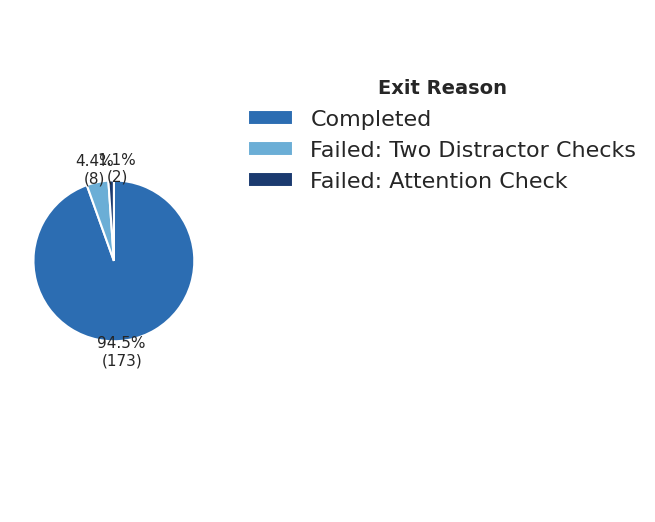

In [9]:
fig, ax = plt.subplots(figsize=(7,6))

exit_counts = profile_df['exit_reason'].value_counts()

pie_colors = [
    colors["color"],
    colors["light_blue"],
    colors["dark_blue"]
][:len(exit_counts)]

wedges, texts, autotexts = ax.pie(
    exit_counts,
    colors=pie_colors,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100 * exit_counts.sum()))})",
    pctdistance=1.15,  # push labels further out
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11)
)

"""fig.suptitle(
    "Human Study: Participant Exit Outcomes",
    fontsize=14,
    y=0.86
)"""

# Slightly adjust overlapping labels manually
for i, txt in enumerate(autotexts):
    x, y = txt.get_position()
    txt.set_position((x - 0.1 + 0.09 * i, y))  # vertical offset


# Legend
legend = ax.legend(
    wedges,
    ["Completed", "Failed: Two Distractor Checks", "Failed: Attention Check"],
    title="Exit Reason",
    loc="center left",
    bbox_to_anchor=(1.05, 0.75),
    frameon=False
)

# Make legend title bold
legend.get_title().set_fontweight("bold")

ax.axis("equal")

plt.tight_layout()
plt.show()

Mean: 13.59 min
Median: 12.26 min
Std: 6.35 min


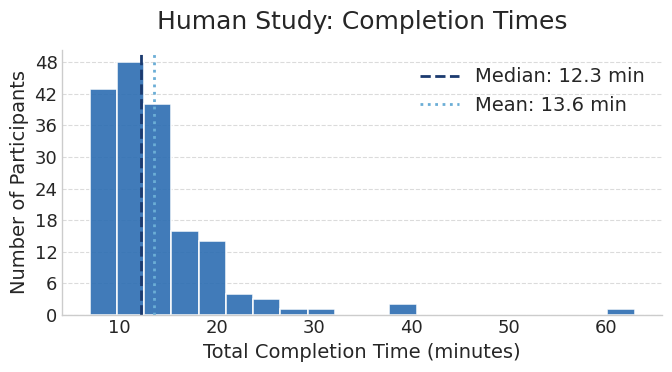

In [10]:
from matplotlib.ticker import MaxNLocator
import numpy as np

completed_profile_df = profile_df[profile_df['exit_reason'] == 'completed'].copy()
completed_profile_df['experiment_start_time'] = pd.to_datetime( completed_profile_df['experiment_start_time'], unit='ms')
completed_profile_df['exit_time'] = pd.to_datetime( completed_profile_df['exit_time'], unit='ms')
completed_profile_df['total_time_min'] = ( completed_profile_df['exit_time'] - completed_profile_df['experiment_start_time'] ).dt.total_seconds() / 60

# Compute median
median_time = completed_profile_df['total_time_min'].median()
mean_time = completed_profile_df['total_time_min'].mean()
std_time = completed_profile_df['total_time_min'].std()

print(f"Mean: {mean_time:.2f} min")
print(f"Median: {median_time:.2f} min")
print(f"Std: {std_time:.2f} min")

fig, ax = plt.subplots(figsize=(7,4))

ax.hist(
    completed_profile_df['total_time_min'],
    bins=20,
    color=colors["color"],   # academic blue
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9
)

# Median line
ax.axvline(median_time, color=colors["dark_blue"], linestyle="--", linewidth=2,
           label=f"Median: {median_time:.1f} min")

ax.axvline(mean_time, color=colors["light_blue"], linestyle=":", linewidth=2,
           label=f"Mean: {mean_time:.1f} min")

ax.set_xlabel("Total Completion Time (minutes)", fontsize=14)
ax.set_ylabel("Number of Participants", fontsize=14)
ax.tick_params(axis="both", labelsize=13)

ax.set_title(
    "Human Study: Completion Times",
    pad=15
)

# nicer y ticks
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# cleaner grid
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.xaxis.grid(False)

ax.legend(frameon=False, fontsize=14)


plt.tight_layout()
plt.show()

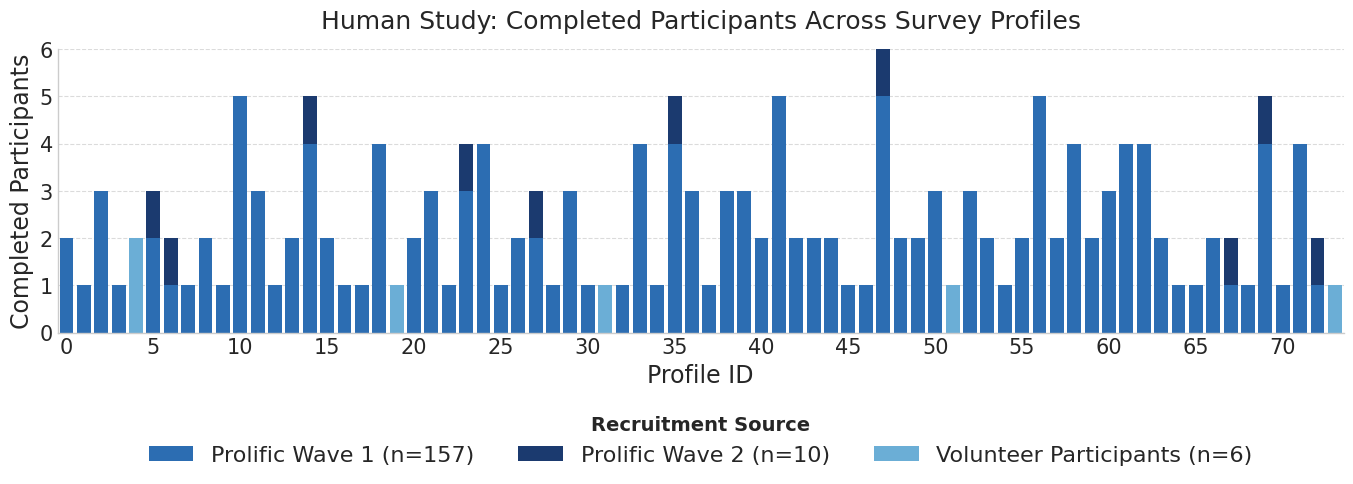

In [11]:
N_PROFILES = 37
intro_positions = ["first", "last"]
all_profiles = [ f"profile_{i}_{pos}" for i in range(N_PROFILES) for pos in intro_positions ]

# main study 
completed_main = profile_df[(profile_df["exit_reason"] == "completed") & (profile_df["study_type"] == "main")].copy()
profile_counts_main = completed_main["profile_id"].value_counts().reindex(all_profiles, fill_value=0)

# volunteers 
completed_volunteers = profile_df[(profile_df["exit_reason"] == "completed") & (profile_df["study_type"] == "volunteer")].copy()
profile_counts_volunteers = completed_volunteers["profile_id"].value_counts().reindex(all_profiles, fill_value=0)

# prolific test run 
completed_prolific_test = profile_df[(profile_df["exit_reason"] == "completed") & (profile_df["study_type"] == "prolific_test")].copy()
profile_counts_prolific_test = completed_prolific_test["profile_id"].value_counts().reindex(all_profiles, fill_value=0)

fig, ax = plt.subplots(figsize=(14,6))

x = range(len(all_profiles))

# Main study
ax.bar(
    x,
    profile_counts_main.values,
    label=f"Prolific Wave 1 (n={profile_counts_main.sum()})",
    color=colors["color"]
)

# Prolific test
ax.bar(
    x,
    profile_counts_prolific_test.values,
    bottom=profile_counts_main.values,
    label=f"Prolific Wave 2 (n={profile_counts_prolific_test.sum()})",
    color=colors["dark_blue"]
)

# Volunteers
ax.bar(
    x,
    profile_counts_volunteers.values,
    bottom=profile_counts_main.values + profile_counts_prolific_test.values,
    label=f"Volunteer Participants (n={profile_counts_volunteers.sum()})",
    color=colors["light_blue"]
)

# Labels
ax.set_xlabel("Profile ID")
ax.set_ylabel("Completed Participants")

ax.set_title(
    "Human Study: Completed Participants Across Survey Profiles", pad=15
)

# Ensure x-axis starts exactly at 0
ax.set_xlim(-0.5, len(all_profiles)-0.5)

# Cleaner tick spacing
step = 5
ax.set_xticks(range(0, len(all_profiles), step))
ax.set_yticks(range(0,7))
ax.set_xticklabels(range(0, len(all_profiles), step))


ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.xaxis.grid(False)


# Move legend outside plot
# Legend below plot
legend = ax.legend(
    title="Recruitment Source",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)
legend.get_title().set_fontweight("bold")

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0,0.08,1,1])
plt.show()

In [12]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

# Custom legend handler for multi-colored line segments
class MultiColorLineHandler(HandlerBase):
    def __init__(self, colors, lw=3, linestyle='-', marker=None, **kwargs):
        self.colors = colors
        self.lw = lw
        self.linestyle = linestyle
        self.marker = marker
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):

        n = len(self.colors)
        segment_width = width / n
        artists = []

        # Continuous segments (no visual gaps)
        for i, color in enumerate(self.colors):
            line = Line2D(
                [x0 + i * segment_width, x0 + (i + 1) * segment_width],
                [y0 + height / 2, y0 + height / 2],
                lw=self.lw,
                color=color,
                linestyle=self.linestyle,
                solid_capstyle='butt',  # removes segment rounding gaps
                transform=trans
            )
            artists.append(line)

        # Optional centered marker
        if self.marker is not None:
            marker = Line2D(
                [x0 + width / 2],
                [y0 + height / 2],
                marker=self.marker,
                color='black',
                markerfacecolor='black',
                markersize=fontsize * 0.6,
                lw=0,
                transform=trans
            )
            artists.append(marker)

        return artists

EXACT THRESHOLD POINTS

All Data:
  - First point where color > 50%: 40% colored (color prop: 0.671)
  - First point where color > 90%: 50% colored (color prop: 0.910)

Canonical Color Prior:
  - First point where color > 50%: 30% colored (color prop: 0.534)
  - First point where color > 90%: 50% colored (color prop: 0.940)

Shape Dataset:
  - First point where color > 50%: 40% colored (color prop: 0.593)
  - First point where color > 90%: 55% colored (color prop: 0.971)

Counterfactual Color Prior:
  - First point where color > 50%: 30% colored (color prop: 0.543)
  - First point where color > 90%: 50% colored (color prop: 0.942)


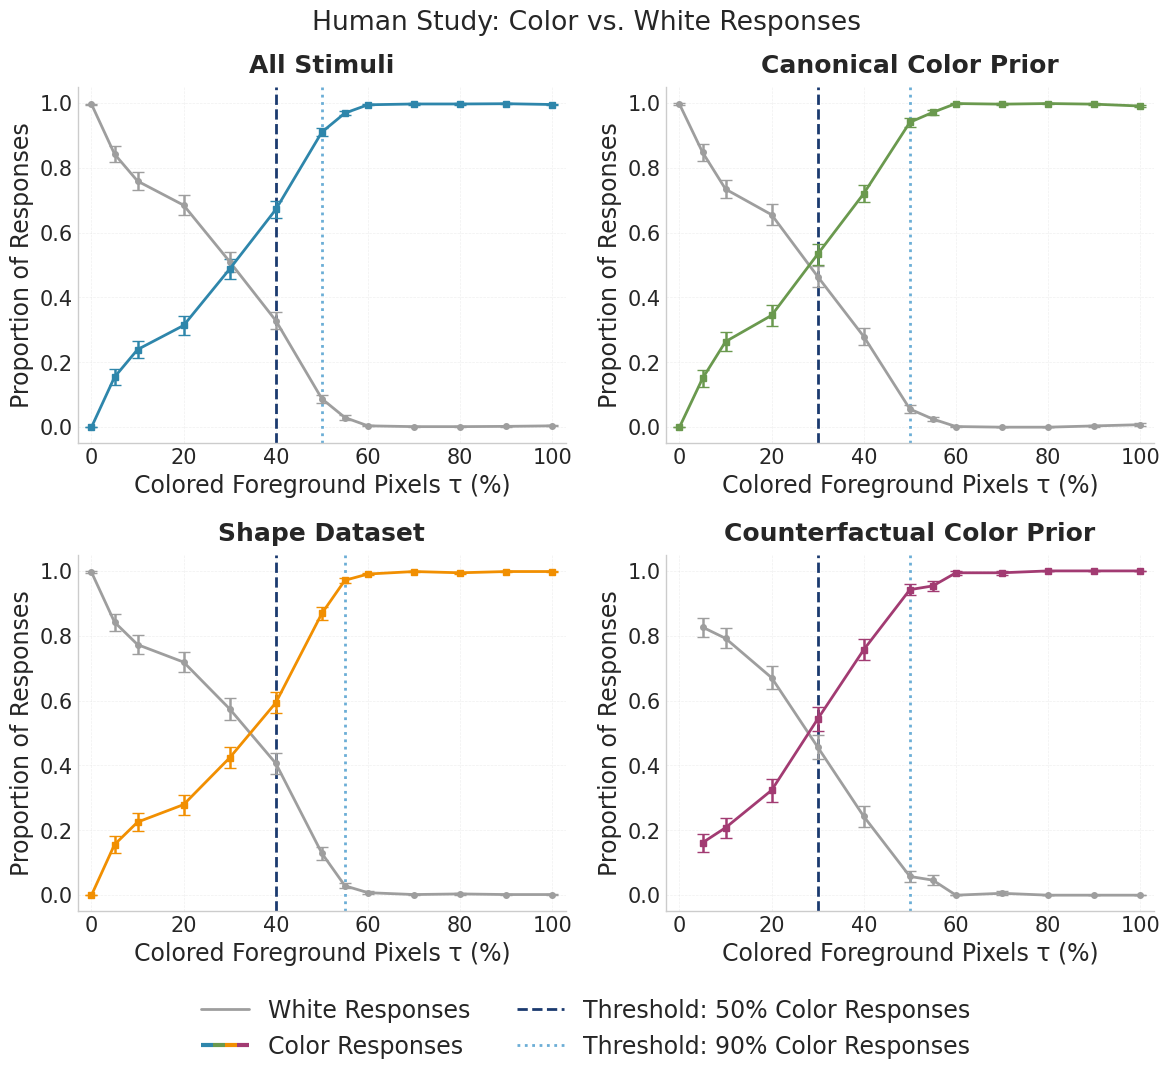

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from matplotlib.legend_handler import HandlerTuple

threshold_colors = {
    "50": colors["dark_blue"],
    "90": colors["light_blue"]
}

# Create binary indicator
df_plot = completed_df.copy()

df_plot = df_plot[df_plot['variant_region'] == 'FG']
#df_plot = df_plot[df_plot['percent_colored'] > 0]

df_plot['white_count'] = (df_plot['response_label'] == 'white').astype(int)
df_plot['color_count'] = (df_plot['response_label'] == df_plot["manipulation_color"]).astype(int)

# Define stimulus types for subplots
stimulus_types = ['correct_prior', 'shape', 'counterfact']
stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# Function to find exact crossover point (50%)
def find_crossover_exact(grouped):
    """Find the first percent_colored where color_count exceeds 0.5"""
    above_50 = grouped[grouped['color_mean'] > 0.5]
    if len(above_50) > 0:
        return above_50['percent_colored'].iloc[0]
    return None

# Function to find exact 90% threshold
def find_90_percent_exact(grouped):
    """Find the first percent_colored where color_count exceeds 0.9"""
    above_90 = grouped[grouped['color_mean'] > 0.9]
    if len(above_90) > 0:
        return above_90['percent_colored'].iloc[0]
    return None

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


print("=" * 70)
print("EXACT THRESHOLD POINTS")
print("=" * 70)

# Plot for all data (subplot 1)
participant_means = (
    df_plot
    .groupby(['subject_id','percent_colored'])
    .agg(
        white_mean=('white_count','mean'),
        color_mean=('color_count','mean')
    )
    .reset_index()
)

grouped_all = (
    participant_means
    .groupby('percent_colored')
    .agg(
        white_mean=('white_mean','mean'),
        white_sem=('white_mean','sem'),
        color_mean=('color_mean','mean'),
        color_sem=('color_mean','sem')
    )
    .reset_index()
    .sort_values('percent_colored')
)

crossover_all = find_crossover_exact(grouped_all)
threshold_90_all = find_90_percent_exact(grouped_all)

print(f"\nAll Data:")
if crossover_all is not None:
    color_val = grouped_all[grouped_all['percent_colored'] == crossover_all]['color_mean'].iloc[0]
    print(f"  - First point where color > 50%: {crossover_all:.0f}% colored (color prop: {color_val:.3f})")
else:
    print(f"  - First point where color > 50%: Not reached")
    
if threshold_90_all is not None:
    color_val = grouped_all[grouped_all['percent_colored'] == threshold_90_all]['color_mean'].iloc[0]
    print(f"  - First point where color > 90%: {threshold_90_all:.0f}% colored (color prop: {color_val:.3f})")
else:
    print(f"  - First point where color > 90%: Not reached")

axes[0].errorbar(
    grouped_all['percent_colored'],
    grouped_all['white_mean'],
    yerr=grouped_all['white_sem'],
    color=colors['white'],
    linewidth=2,
    marker='o',
    markersize=4,
    capsize=4,
    elinewidth=1.8,
    zorder=3,
    label='White responses'
)

axes[0].errorbar(
    grouped_all['percent_colored'],
    grouped_all['color_mean'],
    yerr=grouped_all['color_sem'],
    color=colors['all'],
    linewidth=2,
    marker='s',
    markersize=4,
    capsize=4,
    elinewidth=1.8,
    zorder=3,
    label='Color responses'
)

if crossover_all is not None:
    axes[0].axvline(
        x=crossover_all,
        color=threshold_colors["50"],
        linestyle='--',
        linewidth=2,
        label='50% color responses'
    )

if threshold_90_all is not None:
    axes[0].axvline(
        x=threshold_90_all,
        color=threshold_colors["90"],
        linestyle=':',
        linewidth=2,
        label='90% color responses'
    )
axes[0].set_title('All Stimuli', fontweight='bold', pad=10)
axes[0].grid(alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].set_xlabel('Colored Foreground Pixels τ (%)')
axes[0].set_ylabel('Proportion of Responses')

# Plot for each stimulus type (subplots 2-4)
for idx, stim_type in enumerate(stimulus_types, start=1):
    df_subset = df_plot[df_plot['stimulus_type'] == stim_type]
    
    participant_means = (
        df_subset
        .groupby(['subject_id','percent_colored'])
        .agg(
            white_mean=('white_count','mean'),
            color_mean=('color_count','mean')
        )
        .reset_index()
    )

    grouped = (
        participant_means
        .groupby('percent_colored')
        .agg(
            white_mean=('white_mean','mean'),
            white_sem=('white_mean','sem'),
            color_mean=('color_mean','mean'),
            color_sem=('color_mean','sem')
        )
        .reset_index()
        .sort_values('percent_colored') 
    )
    
    crossover = find_crossover_exact(grouped)
    threshold_90 = find_90_percent_exact(grouped)
    
    print(f"\n{stimulus_labels[stim_type]}:")
    if crossover is not None:
        color_val = grouped[grouped['percent_colored'] == crossover]['color_mean'].iloc[0]
        print(f"  - First point where color > 50%: {crossover:.0f}% colored (color prop: {color_val:.3f})")
    else:
        print(f"  - First point where color > 50%: Not reached")
        
    if threshold_90 is not None:
        color_val = grouped[grouped['percent_colored'] == threshold_90]['color_mean'].iloc[0]
        print(f"  - First point where color > 90%: {threshold_90:.0f}% colored (color prop: {color_val:.3f})")
    else:
        print(f"  - First point where color > 90%: Not reached")
    
    axes[idx].errorbar(
        grouped['percent_colored'],
        grouped['white_mean'],
        yerr=grouped['white_sem'],
        color=colors['white'],
        linewidth=2,
        marker='o',
        markersize=4,
        capsize=4,
        elinewidth=1.8,
        zorder=3,
        label='White responses'
    )

    axes[idx].errorbar(
        grouped['percent_colored'],
        grouped['color_mean'],
        yerr=grouped['color_sem'],
        color=colors[stim_type],
        linewidth=2,
        marker='s',
        markersize=4,
        capsize=4,
        elinewidth=1.8,
        zorder=3,
        label='Color responses'
    )

    if crossover is not None:
        axes[idx].axvline(
            x=crossover,
            color=threshold_colors["50"],
            linestyle='--',
            linewidth=2,
            label='50% color responses'
        )

    if threshold_90 is not None:
        axes[idx].axvline(
            x=threshold_90,
            color=threshold_colors["90"],
            linestyle=':',
            linewidth=2,
            label='90% color responses'
        )

    axes[idx].set_title(stimulus_labels[stim_type],  
                        fontweight='bold', pad=10)
    axes[idx].grid(alpha=0.3, linestyle='--', linewidth=0.5)
    axes[idx].set_xlabel('Colored Foreground Pixels τ (%)')
    axes[idx].set_ylabel('Proportion of Responses')

print("=" * 70)

# Set consistent y-axis limits across all subplots
y_min = min([ax.get_ylim()[0] for ax in axes])
y_max = max([ax.get_ylim()[1] for ax in axes])
for ax in axes:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim(-3, 103)
    ax.set_xticks(range(0, 101, 20))


multi_color_solid = object()

# Add single legend outside the plot
multi_color_handle = (
    Line2D([0], [0], color=colors['all'], lw=3),
    Line2D([0], [0], color=colors['correct_prior'], lw=3),
    Line2D([0], [0], color=colors['shape'], lw=3),
    Line2D([0], [0], color=colors['counterfact'], lw=3),
)

legend_elements = [
    # Response types
    Line2D([0], [0],
           color=colors['white'],
           lw=2,
           linestyle='-',
           label='White response'),

    multi_color_solid,

    Line2D([0], [0], color=threshold_colors["50"],
           lw=2, linestyle='--',
           label='50% threshold'),

    Line2D([0], [0], color=threshold_colors["90"],
           lw=2, linestyle=':',
           label='90% threshold'),
]

legend_labels = [
    'White Responses',
    'Color Responses',
    'Threshold: 50% Color Responses',
    'Threshold: 90% Color Responses'
]

fig.legend(
    legend_elements,
    legend_labels,
    handler_map={
        multi_color_solid: MultiColorLineHandler(
            colors=[
                colors['all'],
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle='-'
        )
    },
    loc='lower center',
    bbox_to_anchor=(0.5, -0.09),
    ncol=2,
    frameon=False,
    fontsize=17
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Human Study: Color vs. White Responses")
plt.show()

EXACT THRESHOLD POINTS

All Data:
  - First point where color > 50%: 30% colored (color prop: 0.558)
  - First point where color > 90%: 50% colored (color prop: 0.941)

Correct Prior:
  - First point where color > 50%: 30% colored (color prop: 0.602)
  - First point where color > 90%: 50% colored (color prop: 0.970)

Shape:
  - First point where color > 50%: 40% colored (color prop: 0.671)
  - First point where color > 90%: 50% colored (color prop: 0.909)

Counterfactual:
  - First point where color > 50%: 30% colored (color prop: 0.623)
  - First point where color > 90%: 50% colored (color prop: 0.948)


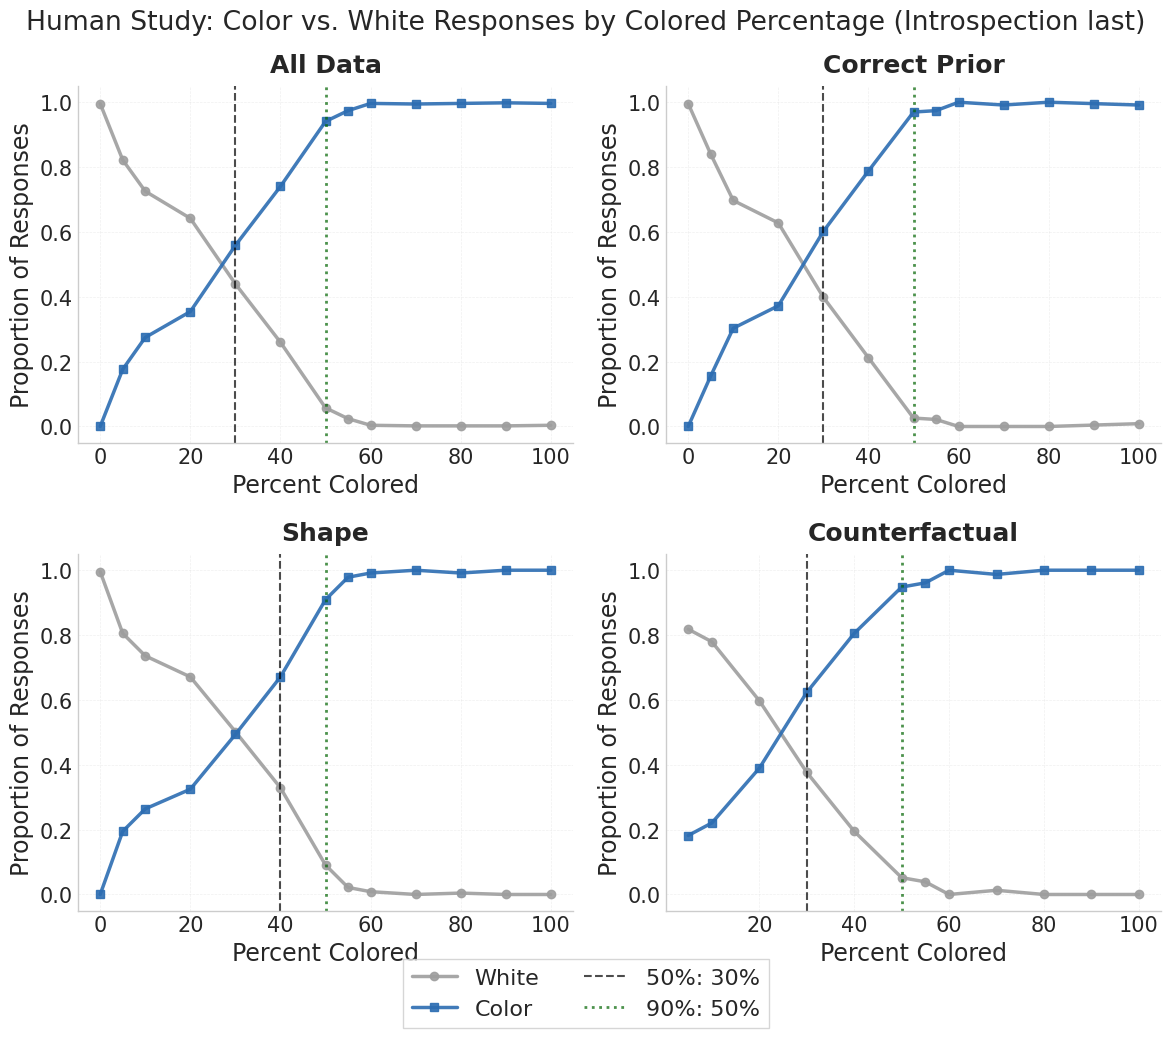

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Create binary indicators
df_plot = completed_df.copy()

df_plot = df_plot[df_plot['variant_region'] == 'FG']
#df_plot = df_plot[df_plot['percent_colored'] > 0]

df_plot = df_plot[df_plot["study_type"] == "main"]


# I WANT FIRST/LAST SPLITS TO BE ON THE SAME GRAPH WITH RELATED COLORS. 
#df_plot = df_plot[df_plot['intro_position'] == 'first']
df_plot = df_plot[df_plot['intro_position'] == 'last']

df_plot['white_count'] = (df_plot['response_label'] == 'white').astype(int)
df_plot['color_count'] = (df_plot['response_label'] == df_plot["manipulation_color"]).astype(int)
#df_plot['color_count'] = (df_plot['response_label'] != 'white').astype(int)

# Define stimulus types for subplots
stimulus_types = ['correct_prior', 'shape', 'counterfact']
stimulus_labels = {
    'correct_prior': 'Correct Prior',
    'shape': 'Shape',
    'counterfact': 'Counterfactual'
}

# Function to find exact crossover point (50%)
def find_crossover_exact(grouped):
    """Find the first percent_colored where color_count exceeds 0.5"""
    above_50 = grouped[grouped['color_count'] > 0.5]
    if len(above_50) > 0:
        return above_50['percent_colored'].iloc[0]
    return None

# Function to find exact 90% threshold
def find_90_percent_exact(grouped):
    """Find the first percent_colored where color_count exceeds 0.9"""
    above_90 = grouped[grouped['color_count'] > 0.9]
    if len(above_90) > 0:
        return above_90['percent_colored'].iloc[0]
    return None

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("=" * 70)
print("EXACT THRESHOLD POINTS")
print("=" * 70)

# Plot for all data (subplot 1)
grouped_all = (
    df_plot
    .groupby('percent_colored')[['white_count', 'color_count']]
    .mean()
    .reset_index()
    .sort_values('percent_colored')
)

crossover_all = find_crossover_exact(grouped_all)
threshold_90_all = find_90_percent_exact(grouped_all)

print(f"\nAll Data:")
if crossover_all is not None:
    color_val = grouped_all[grouped_all['percent_colored'] == crossover_all]['color_count'].iloc[0]
    print(f"  - First point where color > 50%: {crossover_all:.0f}% colored (color prop: {color_val:.3f})")
else:
    print(f"  - First point where color > 50%: Not reached")
    
if threshold_90_all is not None:
    color_val = grouped_all[grouped_all['percent_colored'] == threshold_90_all]['color_count'].iloc[0]
    print(f"  - First point where color > 90%: {threshold_90_all:.0f}% colored (color prop: {color_val:.3f})")
else:
    print(f"  - First point where color > 90%: Not reached")

axes[0].plot(grouped_all['percent_colored'], grouped_all['white_count'], 
             color=colors['white'], linewidth=2.5, marker='o', markersize=6, 
             label='White', alpha=0.9)
axes[0].plot(grouped_all['percent_colored'], grouped_all['color_count'], 
             color=colors['color'], linewidth=2.5, marker='s', markersize=6, 
             label='Color', alpha=0.9)
if crossover_all is not None:
    axes[0].axvline(x=crossover_all, color='black', linestyle='--', 
                    linewidth=1.5, alpha=0.7, label=f'50%: {crossover_all:.0f}%')
if threshold_90_all is not None:
    axes[0].axvline(x=threshold_90_all, color='darkgreen', linestyle=':', 
                    linewidth=2, alpha=0.7, label=f'90%: {threshold_90_all:.0f}%')
axes[0].set_title('All Data', fontweight='bold', pad=10)
axes[0].grid(alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].set_xlabel('Percent Colored')
axes[0].set_ylabel('Proportion of Responses')

# Plot for each stimulus type (subplots 2-4)
for idx, stim_type in enumerate(stimulus_types, start=1):
    df_subset = df_plot[df_plot['stimulus_type'] == stim_type]
    
    grouped = (
        df_subset
        .groupby('percent_colored')[['white_count', 'color_count']]
        .mean()
        .reset_index()
        .sort_values('percent_colored')
    )
    
    crossover = find_crossover_exact(grouped)
    threshold_90 = find_90_percent_exact(grouped)
    
    print(f"\n{stimulus_labels[stim_type]}:")
    if crossover is not None:
        color_val = grouped[grouped['percent_colored'] == crossover]['color_count'].iloc[0]
        print(f"  - First point where color > 50%: {crossover:.0f}% colored (color prop: {color_val:.3f})")
    else:
        print(f"  - First point where color > 50%: Not reached")
        
    if threshold_90 is not None:
        color_val = grouped[grouped['percent_colored'] == threshold_90]['color_count'].iloc[0]
        print(f"  - First point where color > 90%: {threshold_90:.0f}% colored (color prop: {color_val:.3f})")
    else:
        print(f"  - First point where color > 90%: Not reached")
    
    axes[idx].plot(grouped['percent_colored'], grouped['white_count'], 
                   color=colors['white'], linewidth=2.5, marker='o', 
                   markersize=6, label='White', alpha=0.9)
    axes[idx].plot(grouped['percent_colored'], grouped['color_count'], 
                   color=colors['color'], linewidth=2.5, marker='s', 
                   markersize=6, label='Color', alpha=0.9)
    if crossover is not None:
        axes[idx].axvline(x=crossover, color='black', linestyle='--', 
                         linewidth=1.5, alpha=0.7, label=f'50%: {crossover:.0f}%')
    if threshold_90 is not None:
        axes[idx].axvline(x=threshold_90, color='darkgreen', linestyle=':', 
                         linewidth=2, alpha=0.7, label=f'90%: {threshold_90:.0f}%')
    axes[idx].set_title(stimulus_labels[stim_type], 
                        fontweight='bold', pad=10)
    axes[idx].grid(alpha=0.3, linestyle='--', linewidth=0.5)
    axes[idx].set_xlabel('Percent Colored')
    axes[idx].set_ylabel('Proportion of Responses')

print("=" * 70)

# Set consistent y-axis limits across all subplots
y_min = min([ax.get_ylim()[0] for ax in axes])
y_max = max([ax.get_ylim()[1] for ax in axes])
for ax in axes:
    ax.set_ylim([y_min, y_max])

# Add single legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=2, frameon=True, 
           fancybox=False, shadow=False)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Human Study: Color vs. White Responses by Colored Percentage (Introspection last)")
plt.show()

## Introspection

In [15]:
introspection_df = trial_df[(trial_df["task_type"] == "introspection") & (trial_df["exit_reason"] == "completed")].copy()

In [16]:
import pandas as pd
import numpy as np

stimulus_types = ["correct_prior", "counterfact", "shape"]

thresholds = []

for pid, df_pid in completed_df.groupby("subject_id"):

    result = {"subject_id": pid}

    for stim in stimulus_types:

        df = df_pid[
            (df_pid["variant_region"] == "FG") &
            (df_pid["stimulus_type"] == stim)
        ].copy()

        if df.empty:
            result[f"emp_thr_{stim}"] = np.nan
            continue

        df["color_response"] = (
            df["response_label"] == df["target_color"]
        ).astype(int)

        grouped = (
            df.groupby("percent_colored")["color_response"]
            .mean()
            .reset_index()
            .sort_values("percent_colored")
        )

        crossing = grouped[
            (grouped["percent_colored"] > 0) &
            (grouped["color_response"] >= 0.5)
        ]

        if len(crossing) > 0:
            thr = crossing["percent_colored"].iloc[0]
        else:
            thr = np.nan

        result[f"emp_thr_{stim}"] = thr

    thresholds.append(result)

threshold_df = pd.DataFrame(thresholds)

threshold_df = pd.DataFrame(thresholds)
introspection_df = introspection_df.merge(threshold_df, on="subject_id", how="left")

In [17]:
# Combine FIRST and LAST stated thresholds
stated_all = pd.to_numeric(
    introspection_df["response"],
    errors="coerce"
).dropna()

mean_all = stated_all.mean()
median_all = stated_all.median()
std_all = stated_all.std()

print("Combined Stated Thresholds (FIRST + LAST)")
print("-------------------------------------------")
print(f"N      = {len(stated_all)}")
print(f"Mean   = {mean_all:.2f}")
print(f"Median = {median_all:.2f}")
print(f"SD     = {std_all:.2f}")

Combined Stated Thresholds (FIRST + LAST)
-------------------------------------------
N      = 173
Mean   = 56.05
Median = 60.00
SD     = 22.77


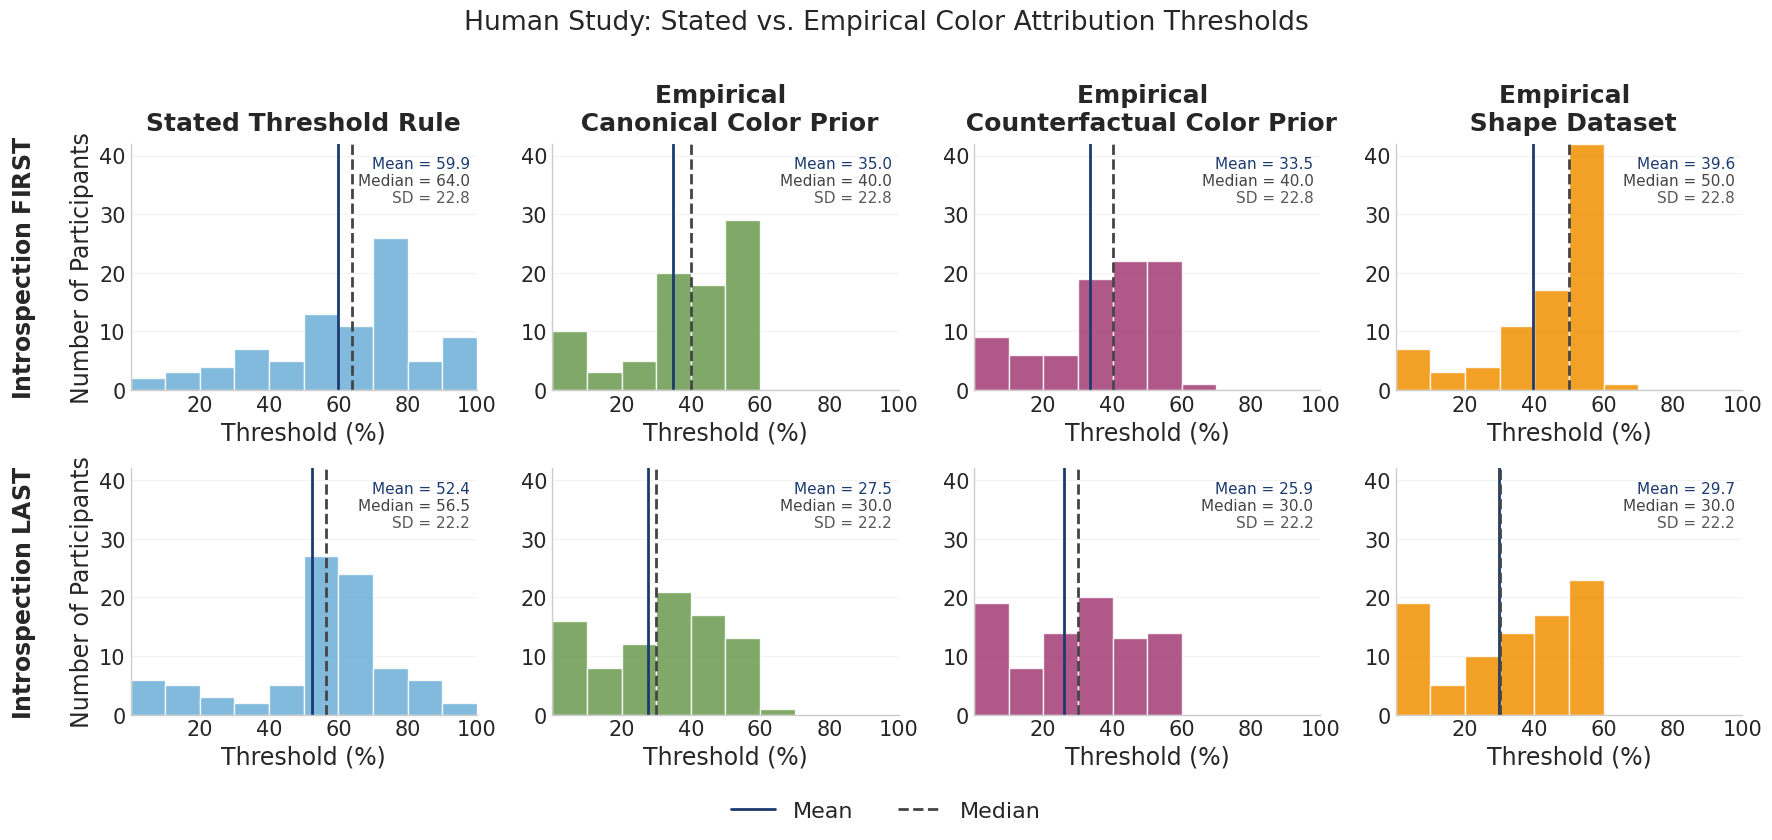

In [18]:
# Optional: restrict to main study only
# introspection_df = introspection_df[introspection_df["study_type"] == "main"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

bins = np.arange(0, 101, 10)

intro_positions = ["first", "last"]
stimulus_types = ["correct_prior", "counterfact", "shape"]

# ---- Compute global y-limit for consistent scaling ----
all_counts = []

for intro in intro_positions:
    df_intro = introspection_df[introspection_df["intro_position"] == intro]

    # stated
    stated = pd.to_numeric(df_intro["response"], errors="coerce").dropna()
    counts, _ = np.histogram(stated, bins=bins)
    all_counts.append(counts.max())

    # empirical
    for stim in stimulus_types:
        emp = df_intro[f"emp_thr_{stim}"].dropna()
        counts, _ = np.histogram(emp, bins=bins)
        if len(counts) > 0:
            all_counts.append(counts.max())

ymax = max(all_counts)


for row_idx, intro in enumerate(intro_positions):

    df_intro = introspection_df[
        introspection_df["intro_position"] == intro
    ]

    # ==========================================================
    # Column 1: STATED RULE
    # ==========================================================
    ax = axes[row_idx, 0]

    stated = pd.to_numeric(df_intro["response"], errors="coerce").dropna()

    ax.hist(
        stated,
        bins=bins,
        color=colors["light_blue"],
        edgecolor="white",
        alpha=0.85
    )

    mean_val = stated.mean()
    median_val = stated.median()
    std_val = stated.std()

    ax.axvline(mean_val, color=colors["dark_blue"], linewidth=2)
    ax.axvline(median_val, color=colors["threshold"], linestyle="--", linewidth=2)

    if row_idx == 0:
        ax.set_title("Stated Threshold Rule", fontweight="bold", pad=10)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Threshold (%)")
    ax.set_xticks(np.arange(20, 101, 20))
    ax.set_ylabel(
        rf"$\bf{{Introspection\ {intro.upper()}}}$" 
        "\n"
        "\nNumber of Participants"
    )

    ax.grid(axis="y", alpha=0.25)
    ax.xaxis.grid(False)

     # Colored statistics text
    ax.text(
        0.98, 0.95,
        f"Mean = {mean_val:.1f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
        color=colors["dark_blue"]
    )

    ax.text(
        0.98, 0.88,
        f"Median = {median_val:.1f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
        color=colors["threshold"]
    )

    ax.text(
        0.98, 0.81,
        f"SD = {std_val:.1f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
        color=colors["dark_grey"]
    )

    # ==========================================================
    # Columns 2–4: EMPIRICAL
    # ==========================================================
    for col_offset, stim in enumerate(stimulus_types):

        ax = axes[row_idx, col_offset + 1]

        emp = df_intro[f"emp_thr_{stim}"].dropna()

        ax.hist(
            emp,
            bins=bins,
            color=colors[stim],
            edgecolor="white",
            alpha=0.85
        )

        if len(emp) > 0:
            mean_val = emp.mean()
            median_val = emp.median()

            ax.axvline(mean_val, color=colors["dark_blue"], linewidth=2)
            ax.axvline(median_val, color=colors["threshold"], linestyle="--", linewidth=2)

            ax.text(
                0.98, 0.95,
                f"Mean = {mean_val:.1f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=11,
                color=colors["dark_blue"]
            )

            ax.text(
                0.98, 0.88,
                f"Median = {median_val:.1f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=11,
                color=colors["threshold"]
            )

            ax.text(
                0.98, 0.81,
                f"SD = {std_val:.1f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=11,
                color=colors["dark_grey"]
            )

        if row_idx == 0:
            if stim == "correct_prior":
                ax.set_title("Empirical \n Canonical Color Prior", fontweight="bold", pad=10)
            elif stim == "counterfact":
                ax.set_title("Empirical \n Counterfactual Color Prior", fontweight="bold", pad=10)
            elif stim == "shape":
                ax.set_title("Empirical \n Shape Dataset", fontweight="bold", pad=10)

        ax.set_ylim(0, ymax)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, ymax)
        ax.set_xticks(np.arange(20, 101, 20))
        ax.set_xlabel("Threshold (%)")

        ax.grid(axis="y", alpha=0.25)
        ax.xaxis.grid(False)

legend_elements = [
    Line2D([0], [0], color=colors["dark_blue"], lw=2, label="Mean"),
    Line2D([0], [0], color=colors["threshold"], lw=2, linestyle="--", label="Median")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
    frameon=False
)

plt.suptitle(
    "Human Study: Stated vs. Empirical Color Attribution Thresholds"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

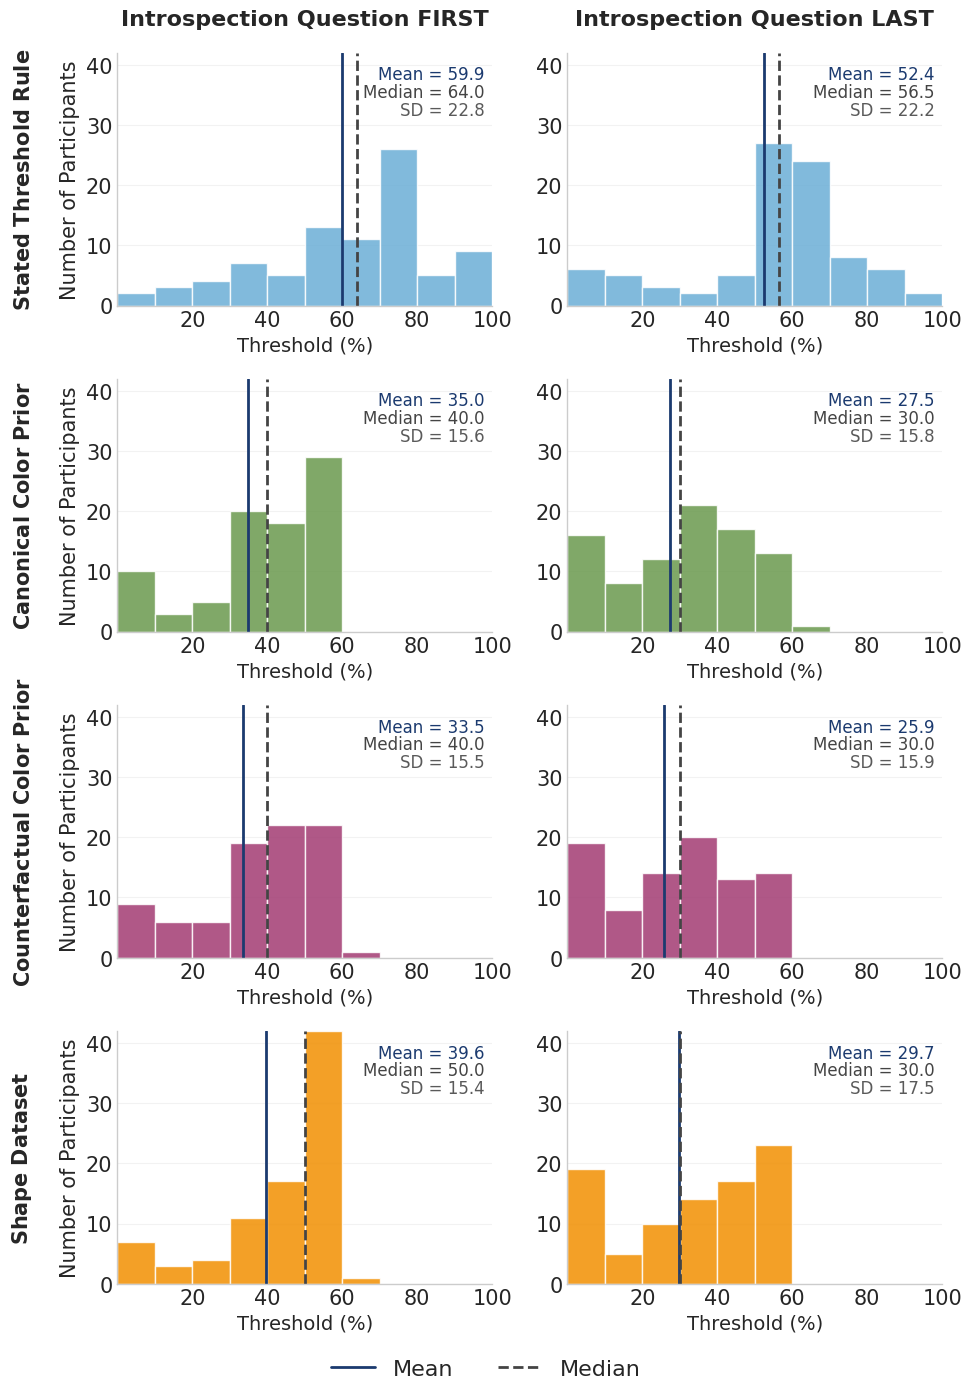

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

bins = np.arange(0, 101, 10)

intro_positions = ["first", "last"]

stimulus_rows = [
    ("Stated Threshold Rule", None, "light_blue"),
    ("Canonical Color Prior", "correct_prior", "correct_prior"),
    ("Counterfactual Color Prior", "counterfact", "counterfact"),
    ("Shape Dataset", "shape", "shape")
]

# ---- Compute global y-limit ----
all_counts = []

for intro in intro_positions:
    df_intro = introspection_df[introspection_df["intro_position"] == intro]

    stated = pd.to_numeric(df_intro["response"], errors="coerce").dropna()
    counts, _ = np.histogram(stated, bins=bins)
    all_counts.append(counts.max())

    for _, stim, _ in stimulus_rows[1:]:
        emp = df_intro[f"emp_thr_{stim}"].dropna()
        counts, _ = np.histogram(emp, bins=bins)
        if len(counts) > 0:
            all_counts.append(counts.max())

ymax = max(all_counts)

# -----------------------------------------------------
# Plotting
# -----------------------------------------------------

for col_idx, intro in enumerate(intro_positions):

    df_intro = introspection_df[
        introspection_df["intro_position"] == intro
    ]

    for row_idx, (row_title, stim, color_key) in enumerate(stimulus_rows):

        ax = axes[row_idx, col_idx]

        # ----- Data selection -----
        if stim is None:
            data = pd.to_numeric(df_intro["response"], errors="coerce").dropna()
        else:
            data = df_intro[f"emp_thr_{stim}"].dropna()

        # ----- Histogram -----
        ax.hist(
            data,
            bins=bins,
            color=colors[color_key],
            edgecolor="white",
            alpha=0.85
        )

        mean_val = data.mean()
        median_val = data.median()
        std_val = data.std()

        ax.axvline(mean_val, color=colors["dark_blue"], linewidth=2)
        ax.axvline(median_val, color=colors["threshold"], linestyle="--", linewidth=2)

        # ----- Stats text -----
        ax.text(
            0.98, 0.95,
            f"Mean = {mean_val:.1f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=12,
            color=colors["dark_blue"]
        )

        ax.text(
            0.98, 0.88,
            f"Median = {median_val:.1f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=12,
            color=colors["threshold"]
        )

        ax.text(
            0.98, 0.81,
            f"SD = {std_val:.1f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=12,
            color=colors["dark_grey"]
        )

        # ----- Axis formatting -----
        ax.set_xlim(0, 100)
        ax.set_ylim(0, ymax)
        ax.set_xticks(np.arange(20, 101, 20))
        ax.set_xlabel("Threshold (%)", fontsize=14)

        ax.grid(axis="y", alpha=0.25)
        ax.xaxis.grid(False)

        # ----- Column titles -----
        if row_idx == 0:
            ax.set_title(
                f"Introspection Question {intro.upper()}",
                fontweight="bold", pad=20, fontsize=16
            )

        # ----- Row labels -----
        if col_idx == 0:
            row_label_math = row_title.replace(" ", r"\ ")

            ax.set_ylabel(
                rf"$\bf{{{row_label_math}}}$" + "\n\nNumber of Participants", fontsize=15
            )
            

# -----------------------------------------------------
# Legend
# -----------------------------------------------------

legend_elements = [
    Line2D([0], [0], color=colors["dark_blue"], lw=2, label="Mean"),
    Line2D([0], [0], color=colors["threshold"], lw=2, linestyle="--", label="Median")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False
)

"""plt.suptitle(
    "Human Study: Stated vs. Empirical FG Color Attribution Thresholds\n(Introspection FIRST vs. LAST)",
    fontsize=16
)"""

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

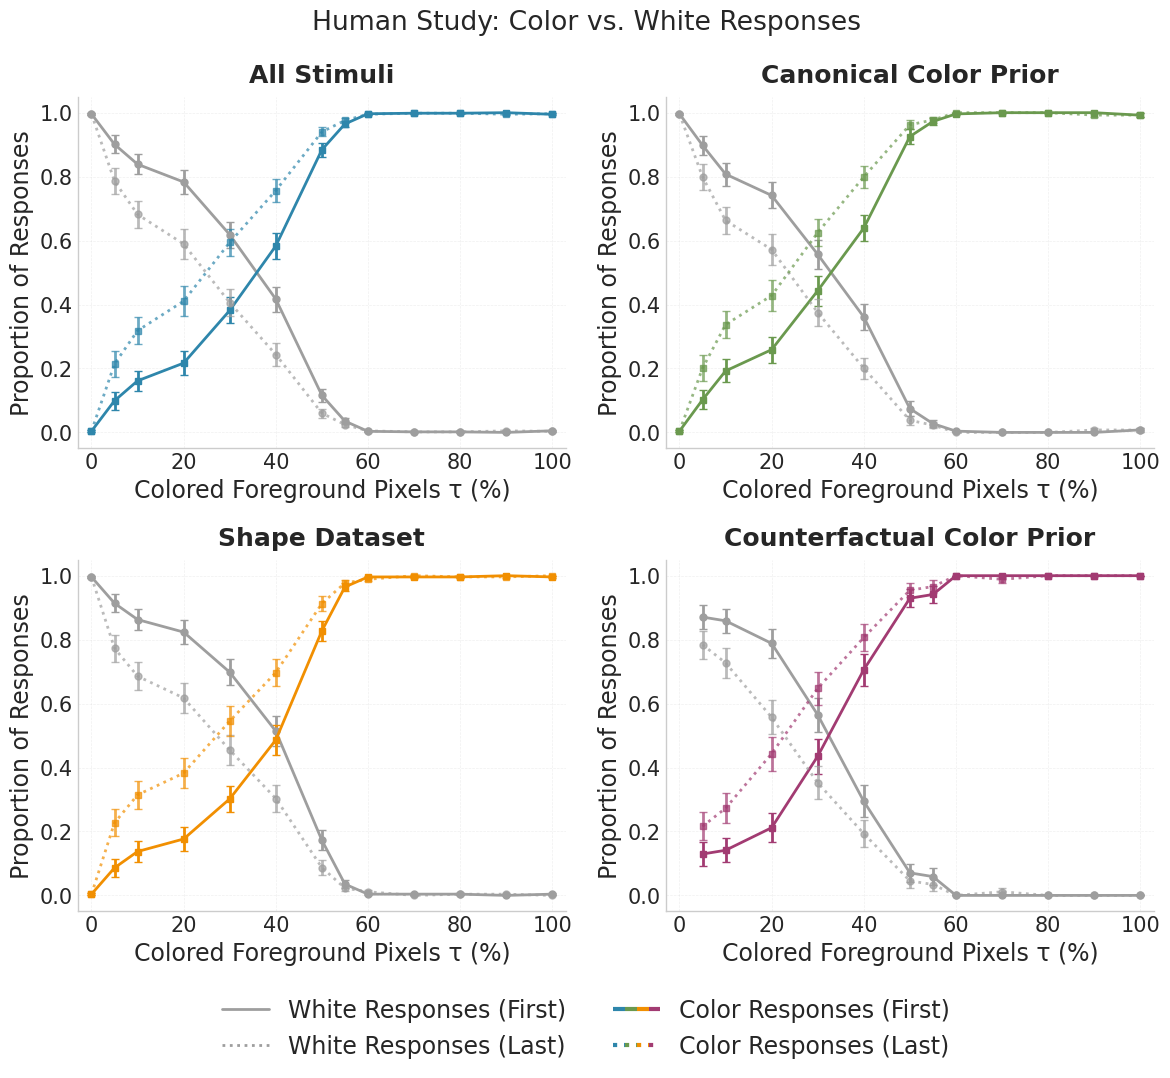

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create binary indicators
df_plot = completed_df.copy()
df_plot = df_plot[df_plot['variant_region'] == 'FG']
#df_plot = df_plot[df_plot['percent_colored'] != 0.0]

df_plot['white_count'] = (df_plot['response_label'] == 'white').astype(int)
df_plot['color_count'] = (df_plot['response_label'] != 'white').astype(int)

stimulus_types = ['correct_prior', 'shape', 'counterfact']
stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# Helper aggregation function
def aggregate_with_sem(df):

    # Step 1 — participant-level averages
    participant_means = (
        df
        .groupby(['subject_id','percent_colored'])
        .agg(
            white_mean=('white_count','mean'),
            color_mean=('color_count','mean')
        )
        .reset_index()
    )

    # Step 2 — SEM across participants
    grouped = (
        participant_means
        .groupby('percent_colored')
        .agg(
            white_mean=('white_mean','mean'),
            white_sem=('white_mean','sem'),
            color_mean=('color_mean','mean'),
            color_sem=('color_mean','sem')
        )
        .reset_index()
        .sort_values('percent_colored')
    )

    return grouped


# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

# =========================
# 1. ALL DATA
# =========================

for position in ['first', 'last']:

    df_subset = df_plot[df_plot['intro_position'] == position]
    grouped = aggregate_with_sem(df_subset)

    linestyle = '-' if position == 'first' else ':'
    alpha = 1.0 if position == 'first' else 0.7

    # White responses (neutral grey)
    axes[0].errorbar(
        grouped['percent_colored'],
        grouped['white_mean'],
        yerr=grouped['white_sem'],
        color=colors['white'],
        marker='o',
        markersize=5,
        linewidth=2,
        capsize=3,
        linestyle=linestyle,
        alpha=alpha,
        label=f'White – {position.capitalize()}',
        zorder=3
    )

    # Color responses (neutral "all" blue)
    axes[0].errorbar(
        grouped['percent_colored'],
        grouped['color_mean'],
        yerr=grouped['color_sem'],
        color=colors['all'],
        marker='s',
        markersize=5,
        linewidth=2,
        capsize=3,
        linestyle=linestyle,
        alpha=alpha,
        label=f'Color – {position.capitalize()}',
        zorder=3
    )

    axes[0].set_title('All Stimuli', fontweight='bold', pad=10)
    axes[0].grid(alpha=0.3, linestyle='--', linewidth=0.5)
    axes[0].set_xlabel('Colored Foreground Pixels τ (%)')
    axes[0].set_ylabel('Proportion of Responses')

# =========================
# 2–4 STIMULUS SUBPLOTS
# =========================

for idx, stim_type in enumerate(stimulus_types, start=1):

    for position in ['first', 'last']:

        df_subset = df_plot[
            (df_plot['stimulus_type']==stim_type) &
            (df_plot['intro_position']==position)
        ]

        grouped = aggregate_with_sem(df_subset)

        if len(grouped)==0:
            continue

        linestyle = '-' if position=='first' else ':'
        alpha = 1.0 if position == 'first' else 0.7

        # White responses (always neutral)
        axes[idx].errorbar(
            grouped['percent_colored'],
            grouped['white_mean'],
            yerr=grouped['white_sem'],
            color=colors['white'],
            marker='o',
            markersize=5,
            linewidth=2,
            capsize=3,
            linestyle=linestyle,
            alpha=alpha,
            label=f'White – {position.capitalize()}',
            zorder=3
        )

        # Color responses (stimulus-specific color)
        axes[idx].errorbar(
            grouped['percent_colored'],
            grouped['color_mean'],
            yerr=grouped['color_sem'],
            color=colors[stim_type],  # ← key change
            marker='s',
            markersize=5,
            linewidth=2,
            capsize=3,
            linestyle=linestyle,
            alpha=alpha,
            label=f'Color – {position.capitalize()}',
            zorder=3
        )

    axes[idx].set_title(stimulus_labels[stim_type], 
                        fontweight='bold', pad=10)
    axes[idx].grid(alpha=0.3, linestyle='--', linewidth=0.5)
    axes[idx].set_xlabel('Colored Foreground Pixels τ (%)')
    axes[idx].set_ylabel('Proportion of Responses')

# Set consistent y-axis limits across all subplots
y_min = min([ax.get_ylim()[0] for ax in axes])
y_max = max([ax.get_ylim()[1] for ax in axes])
for ax in axes:
    ax.set_ylim([y_min, y_max])
    ax.set_xlim(-3, 103)
    ax.set_xticks(range(0, 101, 20))


# Dummy handles
multi_color_solid = object()
multi_color_dotted = object()

legend_elements = [
    # Response types
    Line2D([0], [0],
           color=colors['white'],
           lw=2,
           linestyle='-',
           label='White Responses (First)'),

    # Line style meaning
    Line2D([0], [0],
           color=colors['white'],
           lw=2,
           linestyle=':',
           label='White Responses (Last)'),

    multi_color_solid, 
    multi_color_dotted,
]

legend_labels = [
    'White Responses (First)',
    'White Responses (Last)',
    'Color Responses (First)',
    'Color Responses (Last)'
]

fig.legend(
    legend_elements,
    legend_labels,
    handler_map={
        multi_color_solid: MultiColorLineHandler(
            colors=[
                colors['all'],
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle='-'
        ),
        multi_color_dotted: MultiColorLineHandler(
            colors=[
                colors['all'],
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle=':'
        )
    },
    loc='lower center',
    bbox_to_anchor=(0.5, -0.09),
    ncol=2,
    fontsize=17,
    frameon=False
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Human Study: Color vs. White Responses",
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [21]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

df_test = completed_df.copy()
df_test = df_test[df_test['variant_region'] == 'FG']

df_test['color_response'] = (df_test['response_label'] != 'white').astype(int)

df_test['intro_position'] = df_test['intro_position'].astype('category')
df_test['intro_position'] = df_test['intro_position'].cat.reorder_categories(['first', 'last'])

splits = {
    "All": df_test,
    "Counterfactual": df_test[df_test['stimulus_type'] == 'counterfact'],
    "Correct Prior": df_test[df_test['stimulus_type'] == 'correct_prior'],
    "Shape": df_test[df_test['stimulus_type'] == 'shape']
}

print("=" * 70)
print("LOGISTIC REGRESSION (Adjusted for percent_colored)")
print("=" * 70)

for name, data in splits.items():
    if len(data) == 0:
        continue

    model = smf.logit(
        "color_response ~ C(intro_position) + percent_colored",
        data=data
    ).fit(disp=0)

    coef = model.params['C(intro_position)[T.last]']
    pval = model.pvalues['C(intro_position)[T.last]']
    odds_ratio = np.exp(coef)

    print(f"\n{name}")
    print(f"  Adjusted log-odds (Last vs First): {coef:.4f}")
    print(f"  Adjusted odds ratio: {odds_ratio:.4f}")
    print(f"  p-value: {pval:.6f}")

print("=" * 70)


LOGISTIC REGRESSION (Adjusted for percent_colored)

All
  Adjusted log-odds (Last vs First): 0.8393
  Adjusted odds ratio: 2.3148
  p-value: 0.000000

Counterfactual
  Adjusted log-odds (Last vs First): 0.7838
  Adjusted odds ratio: 2.1898
  p-value: 0.000000

Correct Prior
  Adjusted log-odds (Last vs First): 0.7442
  Adjusted odds ratio: 2.1048
  p-value: 0.000000

Shape
  Adjusted log-odds (Last vs First): 0.9589
  Adjusted odds ratio: 2.6089
  p-value: 0.000000


In [22]:
from statsmodels.stats.proportion import proportions_ztest

print("=" * 70)
print("PER-PERCENT-COLORED SIGNIFICANCE TESTS")
print("=" * 70)

for split_name, data in splits.items():

    print(f"\n===== {split_name} =====")

    for pct in sorted(data['percent_colored'].unique()):

        subset = data[data['percent_colored'] == pct]

        first = subset[subset['intro_position'] == 'first']
        last = subset[subset['intro_position'] == 'last']

        if len(first) == 0 or len(last) == 0:
            continue

        count = np.array([
            first['color_response'].sum(),
            last['color_response'].sum()
        ])

        nobs = np.array([
            len(first),
            len(last)
        ])

        stat, pval = proportions_ztest(count, nobs)

        prop_first = count[0] / nobs[0]
        prop_last = count[1] / nobs[1]

        print(f"\nPercent Colored: {pct}")
        print(f"  First  proportion: {prop_first:.3f} (n={nobs[0]})")
        print(f"  Last   proportion: {prop_last:.3f} (n={nobs[1]})")
        print(f"  z-stat: {stat:.3f}")
        print(f"  p-value: {pval:.6f}")


PER-PERCENT-COLORED SIGNIFICANCE TESTS

===== All =====

Percent Colored: 0.0
  First  proportion: 0.004 (n=510)
  Last   proportion: 0.004 (n=528)
  z-stat: 0.035
  p-value: 0.972276

Percent Colored: 5.0
  First  proportion: 0.099 (n=595)
  Last   proportion: 0.214 (n=616)
  z-stat: -5.495
  p-value: 0.000000

Percent Colored: 10.0
  First  proportion: 0.161 (n=595)
  Last   proportion: 0.318 (n=616)
  z-stat: -6.379
  p-value: 0.000000

Percent Colored: 20.0
  First  proportion: 0.217 (n=595)
  Last   proportion: 0.411 (n=616)
  z-stat: -7.260
  p-value: 0.000000

Percent Colored: 30.0
  First  proportion: 0.382 (n=595)
  Last   proportion: 0.594 (n=616)
  z-stat: -7.400
  p-value: 0.000000

Percent Colored: 40.0
  First  proportion: 0.583 (n=595)
  Last   proportion: 0.756 (n=616)
  z-stat: -6.418
  p-value: 0.000000

Percent Colored: 50.0
  First  proportion: 0.884 (n=595)
  Last   proportion: 0.940 (n=616)
  z-stat: -3.441
  p-value: 0.000579

Percent Colored: 55.0
  First  propo

/mnt/lustre/work/eickhoff/esx061/.conda/envs/thesis/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


# Confidence

AVERAGE FINAL CERTAINTY BY PERCENT COLORED

Introspection First
--------------------------------------------------
All Stimuli:
  - Certainty range: 6.874 to 9.813
Canonical Color Prior:
  - Certainty range: 6.922 to 9.800
Shape Dataset:
  - Certainty range: 6.827 to 9.839
Counterfactual Color Prior:
  - Certainty range: 6.871 to 9.776


Introspection Last
--------------------------------------------------
All Stimuli:
  - Certainty range: 7.586 to 9.873
Canonical Color Prior:
  - Certainty range: 7.667 to 9.822
Shape Dataset:
  - Certainty range: 7.587 to 9.909
Counterfactual Color Prior:
  - Certainty range: 7.341 to 9.920



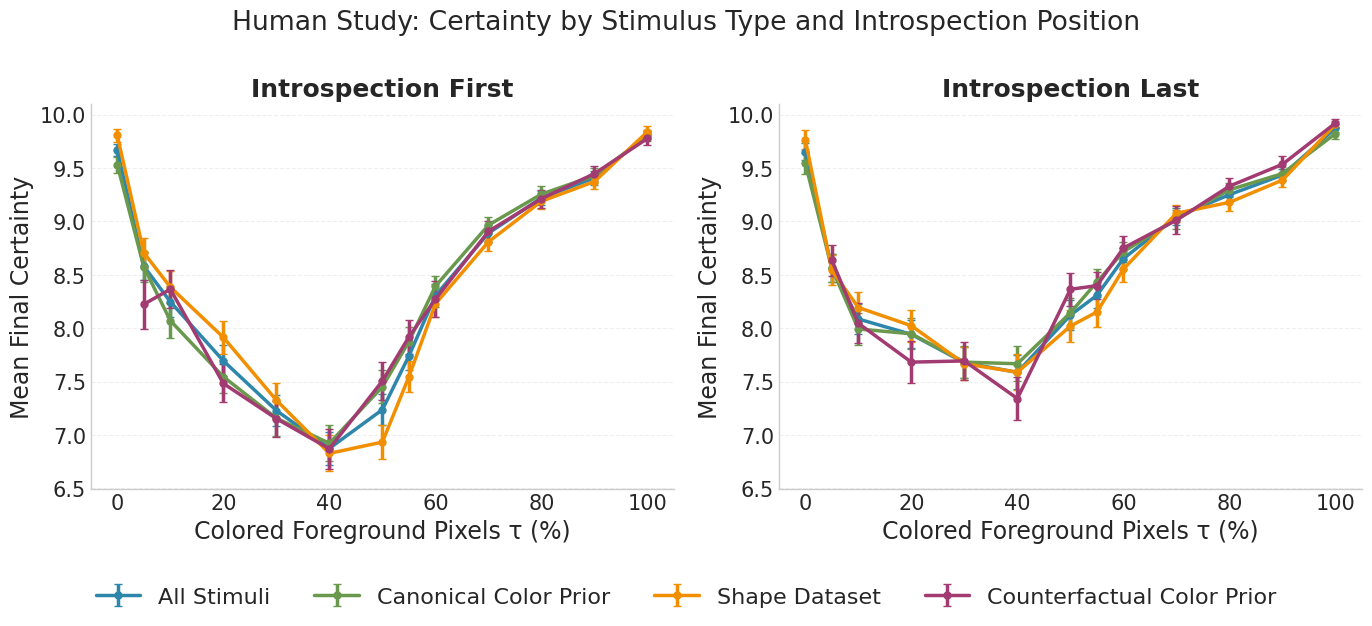

In [23]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = completed_df.copy()
df_plot = df_plot[df_plot['variant_region'] == 'FG']
df_plot['final_certainty'] = df_plot['final_certainty'].fillna(
    df_plot['initial_certainty']
)

stimulus_types = ['correct_prior', 'shape', 'counterfact']
stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

print("=" * 70)
print("AVERAGE FINAL CERTAINTY BY PERCENT COLORED")
print("=" * 70)

for position, ax in [('first', ax1), ('last', ax2)]:

    df_subset = df_plot[df_plot['intro_position'] == position]

    print(f"\nIntrospection {position.capitalize()}")
    print("-" * 50)

    # --- All stimuli ---
    participant_means = (
        df_subset
        .groupby(['subject_id','percent_colored'])['final_certainty']
        .mean()
        .reset_index()
    )

    grouped_all = (
        participant_means
        .groupby('percent_colored')['final_certainty']
        .agg(['mean','std','count'])
        .reset_index()
        .sort_values('percent_colored')
    )

    grouped_all['sem'] = grouped_all['std'] / np.sqrt(grouped_all['count'])

    print("All Stimuli:")
    print(f"  - Certainty range: "
          f"{grouped_all['mean'].min():.3f} "
          f"to {grouped_all['mean'].max():.3f}")

    ax.errorbar(
        grouped_all['percent_colored'],
        grouped_all['mean'],
        yerr=grouped_all['sem'],
        color=colors['all'],
        linewidth=2.5,
        marker='o',
        markersize=5,
        capsize=3,
        label='All Stimuli'
    )

    # --- Individual stimulus types ---
    for stim_type in stimulus_types:

        df_stim = df_subset[df_subset['stimulus_type'] == stim_type]

        participant_means = (
            df_stim
            .groupby(['subject_id','percent_colored'])['final_certainty']
            .mean()
            .reset_index()
        )

        grouped = (
            participant_means
            .groupby('percent_colored')['final_certainty']
            .agg(['mean','std','count'])
            .reset_index()
            .sort_values('percent_colored')
        )

        grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])

        print(f"{stimulus_labels[stim_type]}:")
        print(f"  - Certainty range: "
              f"{grouped['mean'].min():.3f} "
              f"to {grouped['mean'].max():.3f}")

        ax.errorbar(
            grouped['percent_colored'],
            grouped['mean'],
            yerr=grouped['sem'],
            color=colors[stim_type],
            linewidth=2.5,
            marker='o',
            markersize=5,
            capsize=3,
            label=stimulus_labels[stim_type]
        )

    print()

    # --- Formatting ---
    ax.set_title(
        f'Introspection {position.capitalize()}',
        fontweight='bold'
    )

    ax.set_xlabel('Colored Foreground Pixels τ (%)')
    ax.set_ylabel('Mean Final Certainty')

    ax.set_xticks(np.arange(0, 101, 20))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.xaxis.grid(False)

print("=" * 70)

# --- Match y-axis limits ---
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim([y_min, y_max])
ax2.set_ylim([y_min, y_max])

# --- Shared legend ---
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    frameon=False
)

plt.suptitle(
    'Human Study: Certainty by Stimulus Type and Introspection Position',
)

plt.tight_layout(rect=[0, 0.05, 1, 0.99])
plt.show()

INITIAL vs FINAL CERTAINTY (FG & BG, ALL STIMULI)

Foreground - Initial Certainty:
  - Range: 7.249 to 9.828
Foreground - Final Certainty:
  - Range: 7.236 to 9.844

Background - Initial Certainty:
  - Range: 9.520 to 9.575
Background - Final Certainty:
  - Range: 9.535 to 9.607


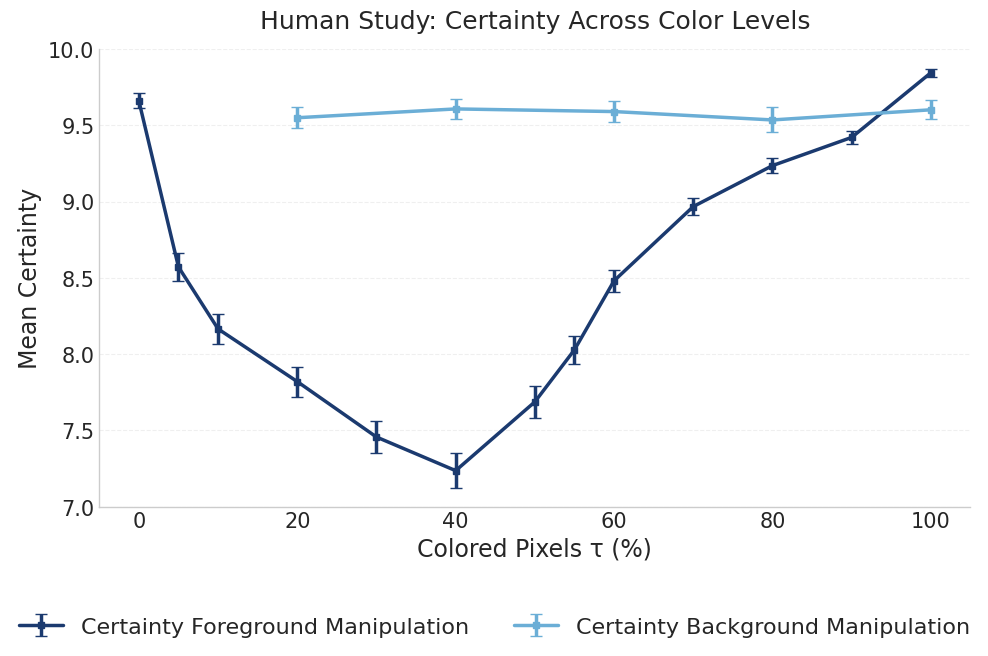

In [31]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = completed_df.copy()

# Replace NaNs in final_certainty with initial_certainty
df_plot['final_certainty_clean'] = df_plot['final_certainty'].fillna(
    df_plot['initial_certainty']
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

print("=" * 70)
print("INITIAL vs FINAL CERTAINTY (FG & BG, ALL STIMULI)")
print("=" * 70)

for region, region_color, region_label in [
    ('FG', colors['dark_blue'], 'Foreground'),
    ('BG', colors['light_blue'], 'Background')
]:

    df_region = df_plot[df_plot['variant_region'] == region]

    # -------------------------
    # Initial Certainty
    # -------------------------
    participant_means = (
        df_region
        .groupby(['subject_id','percent_colored'])[['initial_certainty','final_certainty_clean']]
        .mean()
        .reset_index()
    )

    grouped_initial = (
        participant_means
        .groupby('percent_colored')['initial_certainty']
        .agg(['mean','sem'])
        .reset_index()
    )

    print(f"\n{region_label} - Initial Certainty:")
    print(f"  - Range: {grouped_initial['mean'].min():.3f} "
          f"to {grouped_initial['mean'].max():.3f}")

    """ax.errorbar(
        grouped_initial['percent_colored'],
        grouped_initial['mean'],
        yerr=grouped_initial['sem'],
        color=region_color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        capsize=4,
        linestyle=':',
        label=f'Initial Certainty {region_label} '
    )
"""
    # -------------------------
    # Final Certainty
    # -------------------------
    grouped_final = (
        participant_means
        .groupby('percent_colored')['final_certainty_clean']
        .agg(['mean','sem'])
        .reset_index()
    )    
        

    print(f"{region_label} - Final Certainty:")
    print(f"  - Range: {grouped_final['mean'].min():.3f} "
          f"to {grouped_final['mean'].max():.3f}")

    ax.errorbar(
        grouped_final['percent_colored'],
        grouped_final['mean'],
        yerr=grouped_final['sem'],
        color=region_color,
        linewidth=2.5,
        marker='s',
        markersize=5,
        capsize=4,
        linestyle='-',
        label=f'Certainty {region_label} Manipulation'
    )

print("=" * 70)

# Formatting
ax.set_title(
    'Human Study: Certainty Across Color Levels',
    pad=15
)

ax.set_xlabel('Colored Pixels τ (%)')
ax.set_ylabel('Mean Certainty')
ax.set_ylim(7, 10)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.xaxis.grid(False)

# Remove any ax.legend() if present

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,          # 2 columns keeps it compact (4 entries total)
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom

plt.tight_layout()
plt.show()


UNCERTAINTY CHANGE DISTRIBUTION
certainty_change_count
0.0    16361
1.0      838
2.0       86
3.0       14
4.0        1
Name: count, dtype: int64

Mean change: 0.061
Median change: 0.000


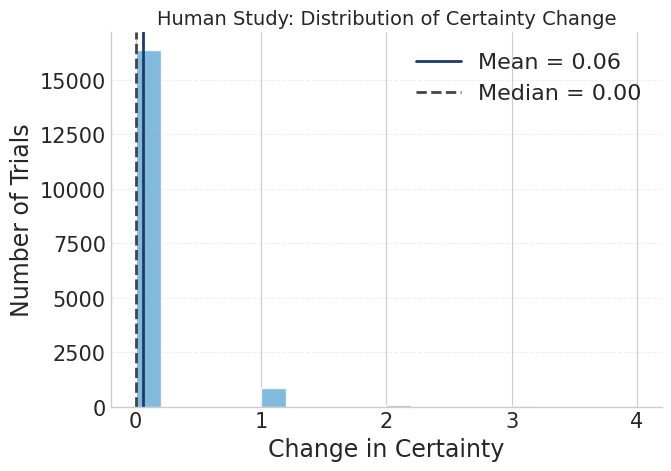

In [25]:
df_plot = completed_df.copy()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

print("\n" + "=" * 70)
print("UNCERTAINTY CHANGE DISTRIBUTION")
print("=" * 70)

# Adjust indexing
df_plot['certainty_change_count'] = df_plot['certainty_change_count'] - 1

change = df_plot['certainty_change_count'].dropna().astype(int)

# Compute statistics
mean_val = change.mean()
median_val = change.median()

print(df_plot["certainty_change_count"].value_counts())
print(f"\nMean change: {mean_val:.3f}")
print(f"Median change: {median_val:.3f}")

# Histogram
ax.hist(
    change,
    bins=20,
    color=colors['light_blue'],
    edgecolor='white',
    alpha=0.85
)

# Mean line
ax.axvline(
    mean_val,
    color=colors['dark_blue'],
    linewidth=2,
    label=f"Mean = {mean_val:.2f}"
)

# Median line
ax.axvline(
    median_val,
    color=colors['threshold'],
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

ax.set_title(
    'Human Study: Distribution of Certainty Change',
    fontsize=14
)

ax.set_xlabel('Change in Certainty')
ax.set_xticks(np.arange(0, 5, 1))
ax.set_ylabel('Number of Trials')

ax.grid(axis='y', linestyle='--', alpha=0.3)

# Proper legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

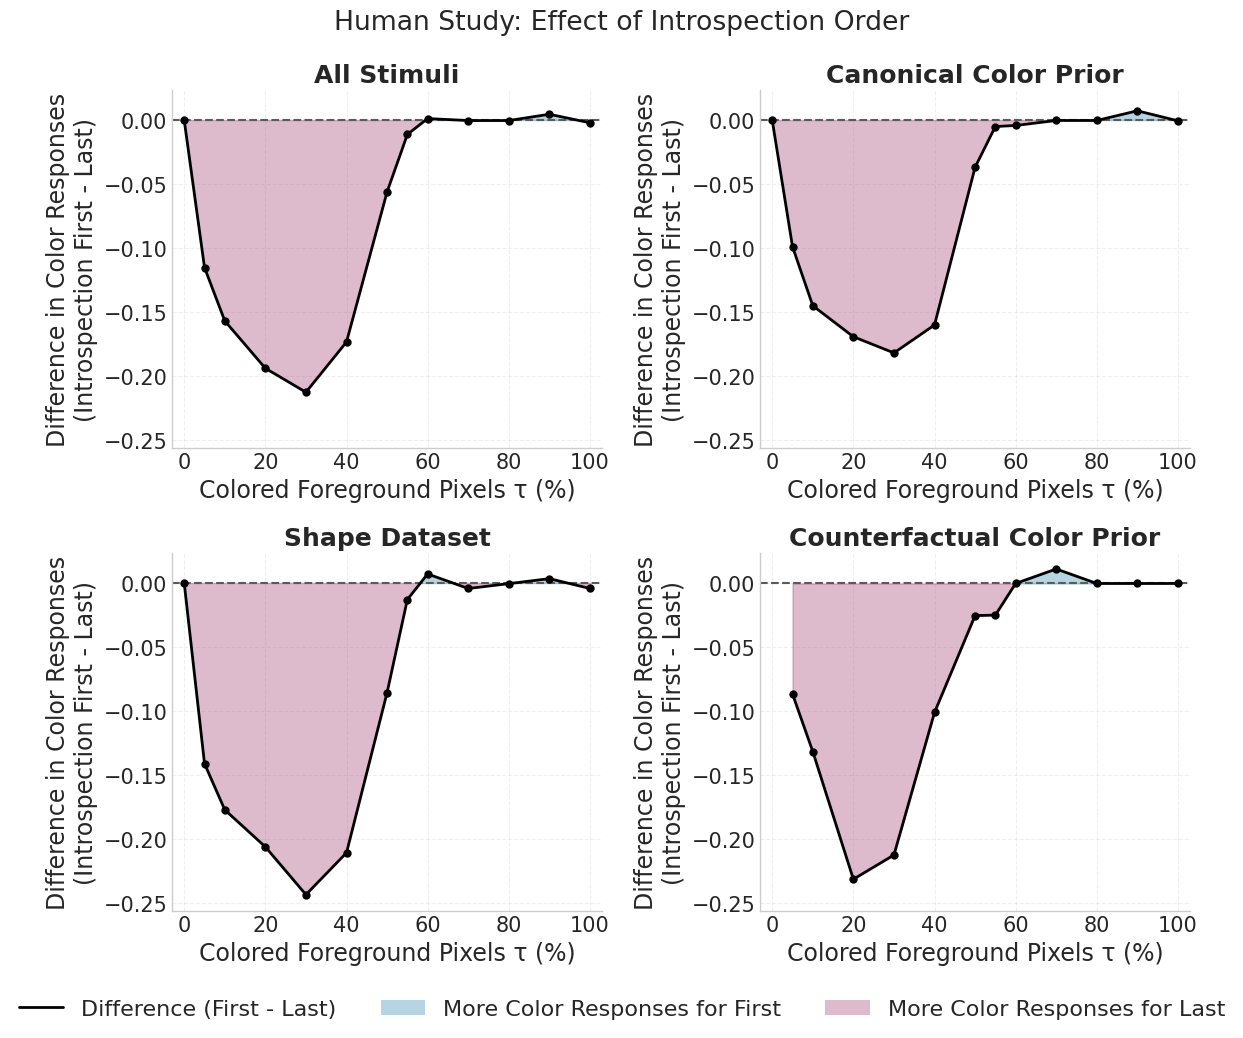

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


df_plot = completed_df.copy()
df_plot = df_plot[df_plot['variant_region'] == 'FG']
#df_plot = df_plot[df_plot['percent_colored'] > 0.0]

stimulus_types = ['all', 'correct_prior', 'shape', 'counterfact']
stimulus_labels = {
    'all': 'All Stimuli',
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# --- Helper function ---
def compute_position_difference(df):

    df_first = df[df['intro_position'] == 'first']
    df_last = df[df['intro_position'] == 'last']

    grouped_first = (
        df_first
        .groupby('percent_colored')['response_label']
        .apply(lambda x: np.mean(x != 'white'))
    )

    grouped_last = (
        df_last
        .groupby('percent_colored')['response_label']
        .apply(lambda x: np.mean(x != 'white'))
    )

    diff = grouped_first - grouped_last

    result = diff.reset_index()
    result.columns = ['percent_colored', 'difference']

    return result.sort_values('percent_colored')


# --- Create figure ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, stim in enumerate(stimulus_types):

    if stim == 'all':
        df_subset = df_plot
    else:
        df_subset = df_plot[df_plot['stimulus_type'] == stim]

    diff_df = compute_position_difference(df_subset)

    x = diff_df['percent_colored']
    y = diff_df['difference']

    ax = axes[idx]

    # Line
    ax.plot(
        x,
        y,
        color='black',
        linewidth=2,
        marker='o',
        markersize=5,
        zorder=3
    )

    # Positive fill (First > Last)
    ax.fill_between(
        x, 0, y,
        where=(y > 0),
        color=colors['all'],  # blue
        alpha=0.35,
        interpolate=True
    )

    # Negative fill (Last > First)
    ax.fill_between(
        x, 0, y,
        where=(y < 0),
        color=colors['counterfact'],  # magenta/pink tone
        alpha=0.35,
        interpolate=True
    )

    # Zero reference line
    ax.axhline(
        0,
        color=colors['dark_grey'],
        linestyle='--',
        linewidth=1.5
    )

    ax.set_title(
        stimulus_labels[stim],
        fontweight='bold'
    )

    ax.set_xlabel('Colored Foreground Pixels τ (%)')
    ax.set_ylabel('Difference in Color Responses\n(Introspection First - Last)')

    ax.grid(linestyle='--', alpha=0.3)

# Match y-limits
y_min = min(ax.get_ylim()[0] for ax in axes)
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_xlim(-3, 103)
    ax.set_ylim(y_min, y_max)

plt.suptitle(
    "Human Study: Effect of Introspection Order"
)

legend_elements = [
    Line2D([0], [0],
           color='black',
           lw=2,
           label='Difference (First - Last)'),

    Patch(facecolor=colors['all'],
          alpha=0.35,
          label='More Color Responses for First'),

    Patch(facecolor=colors['counterfact'],
          alpha=0.35,
          label='More Color Responses for Last')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

BACKGROUND (BG) CONTROL ANALYSIS

Color response range: 0.000 to 0.006


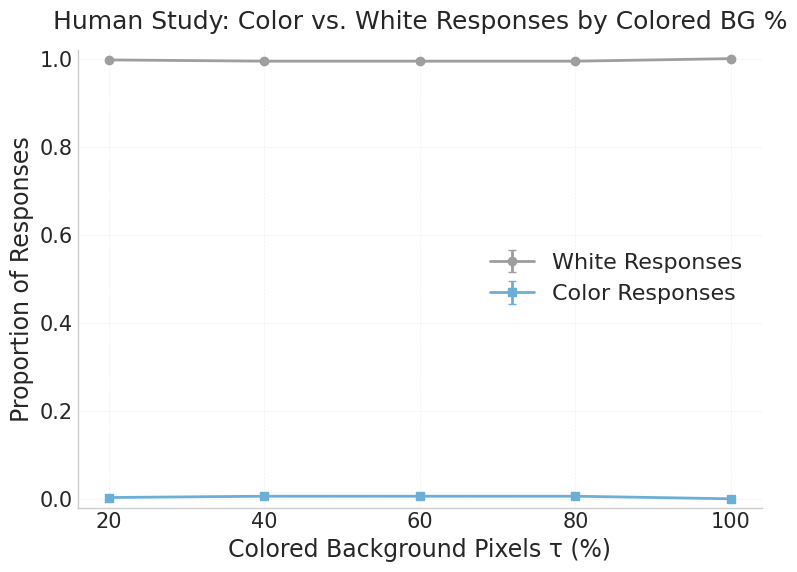

In [27]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = completed_df.copy()
df_plot = df_plot[df_plot['variant_region'] == 'BG']

# Binary indicators
df_plot['white_count'] = (df_plot['response_label'] == 'white').astype(int)
df_plot['color_count'] = (df_plot['response_label'] != 'white').astype(int)

fig, ax = plt.subplots(figsize=(8, 6))

print("=" * 70)
print("BACKGROUND (BG) CONTROL ANALYSIS")
print("=" * 70)

participant_means = (
    df_plot
    .groupby(['subject_id','percent_colored'])
    .agg(
        white_mean=('white_count','mean'),
        color_mean=('color_count','mean')
    )
    .reset_index()
)

grouped = (
    participant_means
    .groupby('percent_colored')
    .agg(
        white_mean=('white_mean','mean'),
        white_sem=('white_mean','sem'),
        color_mean=('color_mean','mean'),
        color_sem=('color_mean','sem')
    )
    .reset_index()
)

print(f"\nColor response range: "
      f"{grouped['color_mean'].min():.3f} "
      f"to {grouped['color_mean'].max():.3f}")

# White responses
ax.errorbar(
    grouped['percent_colored'],
    grouped['white_mean'],
    yerr=grouped['white_sem'],
    color=colors['white'],
    marker='o',
    linewidth=2,
    capsize=3,
    label='White Responses'
)

# Color responses
ax.errorbar(
    grouped['percent_colored'],
    grouped['color_mean'],
    yerr=grouped['color_sem'],
    color=colors['light_blue'],
    marker='s',
    linewidth=2,
    capsize=3,
    label='Color Responses'
)


ax.set_title(
    "Human Study: Color vs. White Responses by Colored BG %", pad=15
)

ax.set_xlabel("Colored Background Pixels τ (%)")
ax.set_ylabel("Proportion of Responses")
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(np.arange(20, 101, 20))
ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

FG vs BG RESPONSE TIMES (seconds)

Foreground Colored:
  RT range: 2.706s to 4.133s

Background Colored:
  RT range: 3.303s to 3.859s

OVERALL RESPONSE TIME STATISTICS (seconds)

Foreground:
  N = 14524
  Mean   = 3.345 s
  Median = 2.531 s
  SD     = 2.640 s

Background:
  N = 1613
  Mean   = 3.550 s
  Median = 2.816 s
  SD     = 2.511 s


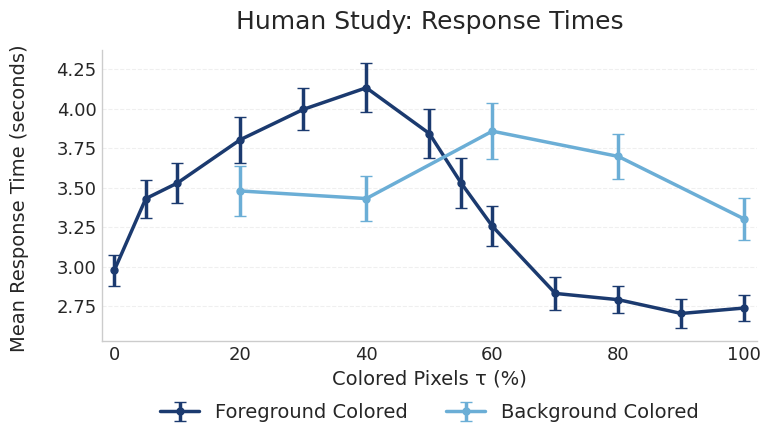

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Copy and clean
df_rt = completed_df.copy()

# Keep valid RTs only
df_rt = df_rt[
    df_rt["color_time"].notna() &
    (df_rt["color_time"] > 0)
].copy()

upper_cut = df_rt["color_time"].quantile(0.99)
df_rt = df_rt[df_rt["color_time"] <= upper_cut]

# Convert ms → seconds
df_rt["color_time"] = df_rt["color_time"] / 1000

fig, ax = plt.subplots(figsize=(8, 5))

print("=" * 60)
print("FG vs BG RESPONSE TIMES (seconds)")
print("=" * 60)

for region, color, label in [
    ("FG", colors['dark_blue'], 'Foreground Colored'),
    ("BG", colors["light_blue"], "Background Colored")
]:

    df_region = df_rt[df_rt["variant_region"] == region]

    participant_means = (
        df_region
        .groupby(['subject_id','percent_colored'])['color_time']
        .mean()
        .reset_index()
    )

    grouped = (
        participant_means
        .groupby('percent_colored')['color_time']
        .agg(mean='mean', sem='sem')
        .reset_index()
    )

    print(f"\n{label}:")
    print(f"  RT range: {grouped['mean'].min():.3f}s "
          f"to {grouped['mean'].max():.3f}s")

    ax.errorbar(
        grouped["percent_colored"],
        grouped["mean"],
        yerr=grouped["sem"],
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=5,
        capsize=4,
        label=label
    )

# ----------------------------
# Overall descriptive statistics
# ----------------------------
print("\n" + "=" * 60)
print("OVERALL RESPONSE TIME STATISTICS (seconds)")
print("=" * 60)

for region, label in [
    ("FG", "Foreground"),
    ("BG", "Background")
]:
    rt_values = df_rt[df_rt["variant_region"] == region]["color_time"]

    print(f"\n{label}:")
    print(f"  N = {len(rt_values)}")
    print(f"  Mean   = {rt_values.mean():.3f} s")
    print(f"  Median = {rt_values.median():.3f} s")
    print(f"  SD     = {rt_values.std():.3f} s")

    
ax.set_title(
    "Human Study: Response Times", pad=15
)

ax.set_xlabel("Colored Pixels τ (%)", fontsize=14)
ax.set_ylabel("Mean Response Time (seconds) \n ", fontsize=14)

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xlim(-2, 102)
ax.tick_params(axis="both", labelsize=13)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.xaxis.grid(False)

ax.legend(frameon=False, fontsize=14, loc='lower center',
    bbox_to_anchor=(0.5, -0.34), ncol=2)

plt.tight_layout()
plt.show()

In [29]:
completed_df[completed_df["color_time"].isna()]["study_type"].value_counts()

study_type
prolific_test    1000
Name: count, dtype: int64

In [30]:
df_rt[(df_rt["variant_region"]=="BG") &
      (df_rt["percent_colored"]==60)]["color_time"].describe()

count    319.000000
mean       3.868311
std        2.836741
min        1.166400
25%        2.200900
50%        2.929700
75%        4.377550
max       17.654700
Name: color_time, dtype: float64